In [ ]:
# CtxPathway = "/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/docs/research/Selected_pathways.csv"

# Load Libraries

In [1]:
import anndata as ad
import squidpy as sq
import cellcharter as cc
import pandas as pd
import scanpy as sc
import scvi
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

/home/jon/anaconda3/envs/spatial_analysis_env/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/jon/anaconda3/envs/spatial_analysis_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [2]:
import liana as li
import geopandas as gpd
from matplotlib.widgets import LassoSelector
from shapely.geometry import Polygon

In [3]:
import ipympl 
%matplotlib widget

In [4]:
import matplotlib
print(matplotlib.get_backend())

widget


# TODO

1. Make a dictionary of samples so that when selecting a sample of interest it also selects the library of origin
2. Move the threshold for interactions to a list of parameters to be able to edit

# Data Prep

In [5]:
# Info
whatFer = "one" # "one" or  "two"

#Load data
#So .X is log1p(CP1e6) (CPM-style per-million normalization, then log1p)
base_folder = Path(f"/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/CellCharterAnalysis/{whatFer}fer/")
adata_file = base_folder / f"{whatFer}fer.h5ad"
# out_figs = base_folder / "figures"
# out_figs = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/")

ST_sample = sc.read_h5ad(adata_file)

In [6]:
# Load nuclei polygons
segmentation_path = Path("/mnt/c/Users/jonan/Documents/1Work/Roselab/Spatial/CAR_T/data/cell_segmentation/")
gdf_file = segmentation_path / "concatenated" / "combined_nuclei_geometry.gpkg"
gdf = gpd.read_file(gdf_file)


ERROR 1: PROJ: proj_create_from_database: Open of /home/jon/anaconda3/envs/spatial_analysis_env/share/proj failed


## Library selection

In [317]:
sample_name = "RTCyPSCA_2_4"
# lib_id = "F07839"
lib_id = "F07840"
lib = lib_id
adata = ST_sample[ST_sample.obs['mouse']==sample_name].copy()

In [318]:
# --- INPUTS you might tweak per run ---
SELECTION_NAME = sample_name 
# SELECTION_NAME = "CyPSCA_1_2"
PAIR_NAME      = "SPP1–CD44"           # label only (for plots/tables)
# thresholds: INT_HIGH percentile is computed *inside* the selection (keeps it local)
pct_int = 0.45 #Interaction cutoff percentile based
pad = 50  # Padding around the cropped area

# Scoring cut offs
t_med_choice = 0.15
t_high_choice = 0.85

# LIANA

In [319]:
li.ut.spatial_neighbors(adata, bandwidth=40, cutoff = 0.1, kernel='gaussian', set_diag=True)
lr = li.mt.bivariate(adata,
                resource_name='mouseconsensus', # NOTE: uses HUMAN gene symbols!
                local_name='cosine', # Name of the function
                global_name="morans", # Name global function
                n_perms=100, # Number of permutations to calculate a p-value
                mask_negatives=False, # Whether to mask LowLow/NegativeNegative interactions
                add_categories=True, # Whether to add local categories to the results
                nz_prop=0.05, # Minimum expr. proportion for ligands/receptors and their subunits
                use_raw=False,
                verbose=False
                )

/home/jon/anaconda3/envs/spatial_analysis_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.


In [320]:
# gdf_file = segmentation_path /  "concatenated" / "combined_nuclei_geometry.gpkg"
# geo_file = gpd.read_file(gdf_file)

# gdf = geo.merge(ST_sample.obs[['id', 'n_counts']], on='id', how='inner')

# Selector

/tmp/ipykernel_8076/1997807963.py:17: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.


[applied] standard → size=(1698.6×1202.7) px center=(6281.8,10197.4) on image 14846×15027


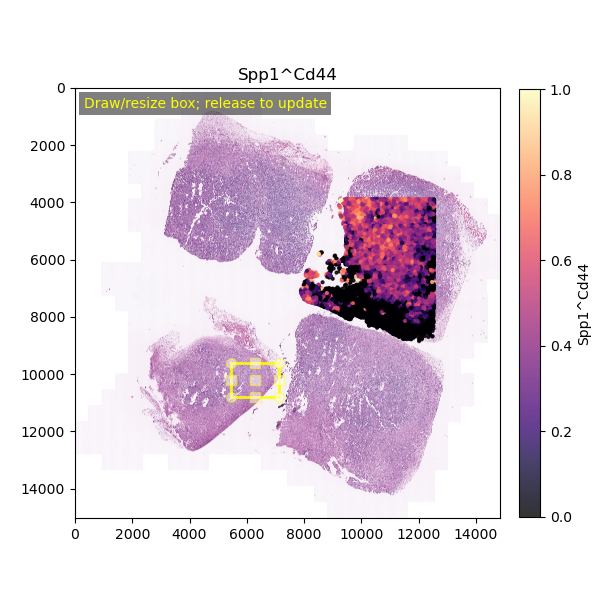

In [323]:
%matplotlib widget
import numpy as np, matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector
import scipy.sparse as sp

pair = "Spp1^Cd44"

img = ST_sample.uns["spatial"][lib]["images"]["hires"]   # full-res HxW[×3]
H, W = img.shape[:2]

# --- data (full-res pixel coords) ---
coords = np.asarray(lr.obsm["spatial"])                  # (n,2) in full-res pixels
vals   = lr[:, pair].X
vals   = vals.toarray().ravel() if sp.issparse(vals) else np.asarray(vals).ravel()

# --- plot image + points in the SAME coordinate system ---
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(img, origin="upper", extent=(0, W, H, 0))      # <- crucial: sets data coords = pixels #Q - What's curcial about this?it maps the image into the same pixel coordinate system as your points (x→columns 0..W, y→rows 0..H with y downward). That way rect.extents (data coords) directly match pixel coordinates and your scatter points line up with the image perfectly.
sc = ax.scatter(coords[:,0], coords[:,1], c=vals, s=4, cmap="magma", alpha=0.8)
fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, label=pair)
ax.set_xlim(0, W); ax.set_ylim(H, 0)                     # y downward like pixels
ax.set_title(pair)

# add once, after ax.set_title(...)
status = ax.text(
    0.02, 0.98, "Draw/resize box; release to update",
    transform=ax.transAxes, va="top", ha="left",
    color="yellow", bbox=dict(facecolor="black", alpha=0.5, pad=3, edgecolor="none")
)


def onselect(eclick, erelease):
    if None in (eclick.xdata, eclick.ydata, erelease.xdata, erelease.ydata):
        status.set_text("Selection cancelled (drag fully inside axes)"); fig.canvas.draw_idle(); return
    x0, x1 = sorted([eclick.xdata,  erelease.xdata])
    y0, y1 = sorted([eclick.ydata,  erelease.ydata])
    sel = (coords[:,0] >= x0) & (coords[:,0] <= x1) & (coords[:,1] >= y0) & (coords[:,1] <= y1)
    state["sel"][:] = sel
    status.set_text(f"Picked: {sel.sum()} cells")
    fig.canvas.draw_idle()

# optional: press Enter to finalize (turn box green & freeze)
def on_key(event):
    if event.key in ("enter","return"):
        rect.set_active(False)
        try: rect.to_draw.set_edgecolor("lime")
        except: pass
        status.set_text(f"Final: {state['sel'].sum()} cells"); fig.canvas.draw_idle()

state = {"sel": np.zeros(coords.shape[0], dtype=bool)}

# make sure pan/zoom isn’t active (ipympl toolbar)
tb = getattr(fig.canvas, "toolbar", None)
if tb is not None:
    tb.mode = ""   # deactivate zoom/pan so events reach the selector

# keep a reference in a global / outer-scope var so it doesn't get GC'd
rect = RectangleSelector(
    ax, onselect,
    button=[1],                 # left mouse
    interactive=True,           # allow resize/move
    useblit=False,              # safer with %matplotlib widget
    drag_from_anywhere=True,    # easier to adjust
    props=dict(edgecolor="yellow", facecolor="none", linewidth=2, alpha=0.9)
)

# === APPLY A SAVED BOX (fractions -> extents for current H×W) ===
# Runs AFTER H,W are known and AFTER rect exists.
import json
from pathlib import Path

BOX_REG_JSON = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/docs/research/rect_boxes.json")
if BOX_REG_JSON.exists():
    try:
        reg = json.loads(BOX_REG_JSON.read_text())
        BOX_KEY = "standard"  # global key
        if BOX_KEY in reg:
            r = reg[BOX_KEY]
            w_frac  = float(r["w_frac"]);  h_frac  = float(r["h_frac"])
            cx_frac = float(r["cx_frac"]); cy_frac = float(r["cy_frac"])

            width_px  = w_frac * float(W)
            height_px = h_frac * float(H)
            cx = cx_frac * float(W)
            cy = cy_frac * float(H)

            xmin = max(0.0, cx - width_px/2)
            xmax = min(float(W), cx + width_px/2)
            ymin = max(0.0, cy - height_px/2)
            ymax = min(float(H), cy + height_px/2)

            # ensure exact size even if clipped
            xmin, xmax = float(xmin), float(xmax)
            ymin, ymax = float(ymin), float(ymax)
            if (xmax - xmin) != width_px:  xmax = xmin + width_px
            if (ymax - ymin) != height_px: ymax = ymin + height_px

            rect.extents = (xmin, xmax, ymin, ymax)
            print(f"[applied] standard → size=({width_px:.1f}×{height_px:.1f}) px "
                  f"center=({cx:.1f},{cy:.1f}) on image {W}×{H}")
        else:
            print("[info] No 'standard' box saved yet — draw your box, then run the SAVE cell to record it.")
    except Exception as e:
        print(f"[warn] Could not load saved box: {e}")
else:
    print("[info] No rect_boxes.json yet — draw your box, then run the SAVE cell to create it.")
    

# finalize on Enter
cid_key = fig.canvas.mpl_connect("key_press_event", on_key)


## Saving Rectangle size

In [30]:
# # === SAVE CURRENT RECTANGLE SIZE (pixels + fractions) ===
# import json, time
# from pathlib import Path
# import pandas as pd
# import numpy as np

# # --- where to keep the saved boxes ---
# BOX_REG_JSON = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/docs/research/rect_boxes.json")
# BOX_REG_CSV  = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/docs/research/rect_boxes_log.csv")
# BOX_REG_JSON.parent.mkdir(parents=True, exist_ok=True)

# # --- identify this box (edit the keying as you like) ---
# # e.g., fix size per library, or keep one "standard" that you reuse everywhere.
# BOX_KEY = f"standard"   # or just "standard", or f"{lib_id}__{pair}"

# # sanity checks
# assert 'rect' in globals(), "RectangleSelector `rect` not found — run the selector cell first."
# assert 'H' in globals() and 'W' in globals(), "H, W not found — run the image cell first."

# # pull extents in data coords (== pixels because of your extent mapping)
# xmin, xmax, ymin, ymax = rect.extents
# width_px  = float(xmax - xmin)
# height_px = float(ymax - ymin)

# # fractions relative to full image
# w_frac = width_px  / float(W)
# h_frac = height_px / float(H)

# # also keep a position anchor in fractions (center is robust across aspect)
# cx_frac = float((xmin + xmax) / 2.0) / float(W)
# cy_frac = float((ymin + ymax) / 2.0) / float(H)

# # store a tidy record
# rec = {
#     "box_key": BOX_KEY,
#     "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
#     "sample_name": str(SELECTION_NAME) if 'SELECTION_NAME' in globals() else None,
#     "lib_id": str(lib_id) if 'lib_id' in globals() else None,
#     "pair": str(pair) if 'pair' in globals() else None,
#     "H": int(H), "W": int(W),
#     "xmin_px": float(xmin), "xmax_px": float(xmax),
#     "ymin_px": float(ymin), "ymax_px": float(ymax),
#     "width_px": width_px, "height_px": height_px,
#     "w_frac": w_frac, "h_frac": h_frac,
#     "cx_frac": cx_frac, "cy_frac": cy_frac,
# }

# # append/update JSON registry
# if BOX_REG_JSON.exists():
#     try:
#         reg = json.loads(BOX_REG_JSON.read_text())
#         if not isinstance(reg, dict): reg = {}
#     except Exception:
#         reg = {}
# else:
#     reg = {}

# reg[BOX_KEY] = rec
# BOX_REG_JSON.write_text(json.dumps(reg, indent=2))

# # also append a CSV log (helpful history)
# row = pd.DataFrame([rec])
# if BOX_REG_CSV.exists():
#     row.to_csv(BOX_REG_CSV, mode="a", header=False, index=False)
# else:
#     row.to_csv(BOX_REG_CSV, index=False)

# print(f"[saved] key={BOX_KEY}  size_px=({width_px:.1f}×{height_px:.1f})  "
#       f"size_frac=({w_frac:.5f}×{h_frac:.5f})  center_frac=({cx_frac:.5f},{cy_frac:.5f})")
# print(f"JSON: {BOX_REG_JSON}")
# print(f"CSV : {BOX_REG_CSV}")

# # --- quick summary for the cell output ---
# print("\nSummary:")
# print(row[["box_key","lib_id","pair","width_px","height_px","w_frac","h_frac","cx_frac","cy_frac"]])


## Applying Mask Selector

In [324]:
# After you draw/adjust the yellow box and release the mouse:
mask = state["sel"].copy()
print("Selected:", mask.sum(), "/", len(mask))

selected_ids = lr.obs.index[mask]
print("First few IDs:", selected_ids[:10].tolist())

# optional: subset objects for downstream plots
lr_sel = lr[mask].copy()
adata_sel = ST_sample[ST_sample.obs.index.isin(selected_ids)].copy()


Selected: 2878 / 18697
First few IDs: ['ID_167289', 'ID_167356', 'ID_167361', 'ID_167391', 'ID_167417', 'ID_167470', 'ID_167516', 'ID_167551', 'ID_167554', 'ID_167563']


Scoring Module

In [325]:
import pandas as pd

# Path to your CSV of curated sets
CtxPathway = "/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/docs/research/Selected_pathways.csv"

# Load & tidy
pth = pd.read_csv(CtxPathway, sep=None, engine="python")
assert {"set_name","genes"}.issubset(pth.columns), pth.columns

# turn the semicolon lists into Python lists
pth["gene_list"] = pth["genes"].astype(str).str.split(r";\s*")

# ---- choose one or many sets here ----
# For now: just the granzyme-mediated pathway (you can add more in the list)
chosen_sets = [
    "GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY",
    # "GOBP_NATURAL_KILLER_CELL_DEGRANULATION",
    # "GOBP_TRAIL_ACTIVATED_APOPTOTIC_SIGNALING_PATHWAY",
]

# Build dict: set_name -> list of genes
set2genes = {
    row.set_name: row.gene_list
    for _, row in pth[pth["set_name"].isin(chosen_sets)].iterrows()
}

print("Selected pathways:", list(set2genes.keys()))
for k, gl in set2genes.items():
    print(f"  {k}: {len(gl)} genes (from CSV)")


Selected pathways: ['GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY']
  GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY: 13 genes (from CSV)


In [326]:
import numpy as np

# case-insensitive map for gene matching
vmap = {g.lower(): g for g in ST_sample.var_names}
def match_genes(glist):
    q = [g.lower() for g in glist]
    kept    = [vmap[g] for g in q if g in vmap]
    missing = [g for g in glist if g.lower() not in vmap]
    return kept, missing

matched = {}
for setname, glist in set2genes.items():
    kept, missing = match_genes(glist)
    matched[setname] = kept
    print(f"\n[{setname}] kept={len(kept)}  missing={len(missing)}")
    if missing:
        print("  Missing:", missing)

# safety check
total_kept = sum(len(v) for v in matched.values())
assert total_kept > 0, "No genes from chosen pathways were found in ST_sample.var_names."



[GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY] kept=12  missing=1
  Missing: ['Gsdme']


In [327]:
import scanpy as sc

# Use a raw-ish layer if you keep counts there; otherwise .X
# If you want to force a particular layer: sc.pp.normalize_total(...) before scoring, or set `use_raw=True`.
use_raw = False

for setname, glist in matched.items():
    score_col = f"{setname}__score"
    sc.tl.score_genes(
        ST_sample,
        glist,
        score_name=score_col,
        use_raw=use_raw,     # False = use .X; True = use .raw
        ctrl_size=50,        # Seurat-like background correction
        copy=False
    )
    print(f"Scored: {score_col} (head) ->", ST_sample.obs[score_col].head().round(3).tolist()[:5])

Scored: GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY__score (head) -> [0.436, -0.025, 0.395, 0.0, 1.302]


In [328]:
# PRETTY SURE THIS IS A REDUNDANT CELL BLOCK. i HAVE NO IDEA WHY IS THIS HERE, BECAUSE NEXT BLOCK RECALCULATES THIS SHIT AGAIN!
# ..... Keeping it here incase something breaks. 
# # Choose which score column to visualize now
# score_col = "GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY__score"

# # align to lr.obs order
# score_all = ST_sample.obs.loc[lr.obs.index, score_col].to_numpy()

# # --- thresholds (quantiles) computed inside your rectangular selection ---
# sel = mask.copy()                   # from your selector
# vals_sel   = vals[sel]              # interaction values inside selection
# score_sel  = score_all[sel]

# # interaction high threshold (same p as you used; adjust as you like)
# # pct_int   = 0.45
# thr_int   = np.quantile(vals_sel, pct_int) if sel.any() else np.quantile(vals, pct_int)

# # module-score high threshold (use top 40% by default for visibility)
# pct_score = 0.60
# thr_score = np.quantile(score_sel, pct_score) if sel.any() else np.quantile(score_all, pct_score)

# int_high  = vals >=  thr_int
# score_hi  = score_all > thr_score

# # categories (priority to interaction)
# INT_HIGH  = sel & int_high
# GENE_ONLY = sel & (~int_high) & score_hi
# OTHER     = sel & (~int_high) & (~score_hi)

# print(f"Thresholds -> INT thr={thr_int:.3g} (p{int(pct_int*100)}), SCORE thr={thr_score:.3g} (p{int(pct_score*100)})")
# print(f"Counts in selection -> INT_HIGH={INT_HIGH.sum()}, GENE_ONLY={GENE_ONLY.sum()}, OTHER={OTHER.sum()}")


# Prepping selected data

## Categorizing

In [329]:
# If you already chose t_med/t_high earlier, reuse them; otherwise define sensible defaults once
if "t_med" not in globals() or "t_high" not in globals():
    score_col = "GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY__score"
    scores_all = ST_sample.obs[score_col].to_numpy()
    t_med  = t_med_choice #0.15
    t_high = t_high_choice #0.85 #float(np.quantile(scores_all, 0.95))
    print(f"[Init cutoffs] MED ≥ {t_med:.3f}, VHIGH ≥ {t_high:.3f}")

# --- pull everything aligned to lr.obs order ---
score_col = "GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY__score"
scores_aligned = ST_sample.obs.loc[lr.obs.index, score_col].to_numpy()

# Your existing SPP1^CD44 interaction vector "vals" and selection "mask" come from earlier cells
sel = mask.copy()
n_sel = int(sel.sum())
assert n_sel > 0, "No cells selected — draw the yellow box first."


thr_int = float(np.quantile(vals[sel], pct_int)) if sel.any() else float(np.quantile(vals, pct_int))

# masks only *within* the selection
INT_HIGH_mask   = sel & (vals >= thr_int)
CYTO_VHIGH_mask = sel & (~INT_HIGH_mask) & (scores_aligned >= t_high)
CYTO_MED_mask   = sel & (~INT_HIGH_mask) & (scores_aligned >= t_med) & (scores_aligned < t_high)

# counts limited to the selection
n_int   = int(INT_HIGH_mask.sum())
n_med   = int(CYTO_MED_mask.sum())
n_high  = int(CYTO_VHIGH_mask.sum())

# proportions within the selection (this is the key change)
p_int   = n_int  / n_sel
p_med   = n_med  / n_sel
p_high  = n_high / n_sel

print(f"[{SELECTION_NAME}] n_sel={n_sel} | INT_HIGH={n_int} ({p_int:.3f}) | "
      f"CYTO_MED={n_med} ({p_med:.3f}) | CYTO_VHIGH={n_high} ({p_high:.3f})")

# small summary row kept in-memory for the next cell
sel_row = {
    "selection": SELECTION_NAME,
    "pair_label": PAIR_NAME,
    "n_sel": n_sel,
    "n_int": n_int, "n_med": n_med, "n_high": n_high,
    "p_int": p_int, "p_med": p_med, "p_high": p_high,
    "t_med": t_med, "t_high": t_high, "thr_int": thr_int,
    "pct_int": pct_int,
}
pd.DataFrame([sel_row])

[RTCyPSCA_2_4] n_sel=2878 | INT_HIGH=1583 (0.550) | CYTO_MED=398 (0.138) | CYTO_VHIGH=209 (0.073)


,selection,pair_label,n_sel,n_int,n_med,n_high,p_int,p_med,p_high,t_med,t_high,thr_int,pct_int
0,RTCyPSCA_2_4,SPP1–CD44,2878,1583,398,209,0.550035,0.13829,0.07262,0.15,0.85,0.417801,0.45


## Logging

In [331]:
from pathlib import Path
# Logs data and adds a replicate depending on whether this selection name exists already


# where to accumulate your selection summaries
RUN_LOG = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/selection_runs.csv")
RUN_LOG.parent.mkdir(parents=True, exist_ok=True)

# --- compute replicate number for this selection name ---
import pandas as pd, csv
if RUN_LOG.exists():
    prev = pd.read_csv(RUN_LOG)
    # count existing reps for this SELECTION_NAME (sample)
    rep = int(prev.loc[prev["selection"] == SELECTION_NAME, "rep"].max() + 1) if "rep" in prev.columns and (prev["selection"] == SELECTION_NAME).any() else 1
else:
    rep = 1

# augment sel_row and write
sel_row["rep"] = rep

write_header = not RUN_LOG.exists()
with RUN_LOG.open("a", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(sel_row.keys()))
    if write_header: w.writeheader()
    w.writerow(sel_row)

print(f"Appended selection '{SELECTION_NAME}' (rep={rep}) → {RUN_LOG}")

# quick peek at trailing rows
runs = pd.read_csv(RUN_LOG)
display(runs.tail(6))


Appended selection 'RTCyPSCA_2_4' (rep=3) → /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/selection_runs.csv


,selection,pair_label,n_sel,n_int,n_med,n_high,p_int,p_med,p_high,t_med,t_high,thr_int,pct_int,rep
9,RTCyPSCA_1_4,SPP1–CD44,1335,734,109,29,0.549813,0.081648,0.021723,0.15,0.85,0.354214,0.45,1
10,RTCyPSCA_1_4,SPP1–CD44,1100,605,114,25,0.550000,0.103636,0.022727,0.15,0.85,0.471092,0.45,2
11,RTCyPSCA_1_4,SPP1–CD44,1229,676,119,34,0.550041,0.096827,0.027665,0.15,0.85,0.340370,0.45,3
12,RTCyPSCA_2_4,SPP1–CD44,2781,1530,381,226,0.550162,0.137001,0.081266,0.15,0.85,0.470579,0.45,1
13,RTCyPSCA_2_4,SPP1–CD44,2656,1461,308,109,0.550075,0.115964,0.041039,0.15,0.85,0.499912,0.45,2
14,RTCyPSCA_2_4,SPP1–CD44,2878,1583,398,209,0.550035,0.138290,0.072620,0.15,0.85,0.417801,0.45,3


# Plotting Selection

## Creating crop

In [332]:
# Rebuild prerequisites for plotting the crop after a restart or new selection.

import numpy as np, pandas as pd
from shapely.affinity import translate

# 1) Must have these already defined by earlier cells:
#    ST_sample, lr, gdf, vals, mask (selection), score_col or t_med/t_high
assert 'ST_sample' in globals() and 'lr' in globals() and 'gdf' in globals(), "Load data first."
assert 'vals' in globals(), "Compute interaction vector `vals` first (your LIANA step)."
assert 'mask' in globals(), "Run the RectangleSelector cell and create `mask`."
sel = mask.copy()
assert sel.any(), "Selection is empty — draw/resize the yellow box and re-run."

# 2) Image + sizes
lib = list(ST_sample.uns["spatial"].keys())[0] if 'lib' not in globals() else lib
img = ST_sample.uns["spatial"][lib]["images"]["hires"]   # HxW[×3]
H, W = img.shape[:2]

# 3) Spatial coords (full-res pixel frame)
coords_all = np.asarray(lr.obsm["spatial"])
coords_sel = coords_all[sel]
assert coords_sel.size, "Selected coords array is empty."

# 4) Compute crop box around selection
# pad = 50 
xmin = max(0, int(np.floor(coords_sel[:,0].min()) - pad))
xmax = min(W, int(np.ceil (coords_sel[:,0].max()) + pad))
ymin = max(0, int(np.floor(coords_sel[:,1].min()) - pad))
ymax = min(H, int(np.ceil (coords_sel[:,1].max()) + pad))
img_crop = img[ymin:ymax, xmin:xmax]
h, w = int(img_crop.shape[0]), int(img_crop.shape[1])
assert h >= 2 and w >= 2, f"Crop too small (h={h}, w={w}); try increasing pad."

# 5) Ensure polygon IDs and subset to selection
if "id" not in gdf.columns:
    gdf = gdf.reset_index().rename(columns={"index":"id"})
sel_ids = lr.obs.index[sel]
gdf_sel = gdf[gdf["id"].isin(sel_ids)].copy()

# 6) Build/update masks if missing (CYTO_MED/VHIGH/INT_HIGH) — all within selection
score_col = "GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY__score"
scores_aligned = ST_sample.obs.loc[lr.obs.index, score_col].to_numpy()
# if "t_med" not in globals() or "t_high" not in globals():
#     t_med  = 0.15
#     t_high = float(np.quantile(ST_sample.obs[score_col].to_numpy(), 0.95))

# pct_int = 0.55 
thr_int = float(np.quantile(vals[sel], pct_int))

INT_HIGH_mask   = sel & (vals >= thr_int)
CYTO_VHIGH_mask = sel & (~INT_HIGH_mask) & (scores_aligned >= t_high)
CYTO_MED_mask   = sel & (~INT_HIGH_mask) & (scores_aligned >= t_med) & (scores_aligned < t_high)

# 7) Category map for polygons (priority: INT_HIGH > VHIGH > MED > OTHER)
cat = np.full(lr.shape[0], "OTHER", dtype=object)
cat[CYTO_MED_mask]   = "CYTO_MED"
cat[CYTO_VHIGH_mask] = "CYTO_VHIGH"
cat[INT_HIGH_mask]   = "INT_HIGH"
gdf_sel["category"]  = gdf_sel["id"].map(pd.Series(cat, index=lr.obs.index))

# 8) Shift polygons into crop frame and attach interaction values
gdf_sel["geometry"] = gdf_sel["geometry"].apply(lambda geom: translate(geom, xoff=-xmin, yoff=-ymin))
gdf_sel["int_val"]  = gdf_sel["id"].map(pd.Series(vals, index=lr.obs.index))

print(f"[Crop ready] img_crop: {img_crop.shape}, box=({xmin},{xmax},{ymin},{ymax}); "
      f"INT={INT_HIGH_mask.sum()}, VHIGH={CYTO_VHIGH_mask.sum()}, MED={CYTO_MED_mask.sum()}")


[Crop ready] img_crop: (1303, 1796, 3), box=(10242,12038,5719,7022); INT=1583, VHIGH=209, MED=398


## Prepping colors

In [333]:
# --- palettes (redefine every fresh run) ---
import matplotlib.cm as cm
from matplotlib.colors import Normalize

col_other     = "#5d6673"  # 10% brighter than #4b5563#"#4b5563" - Darker

col_cyto_med  = "#7dd3fc"  # sky blue
edge_col_cyto_med = "#1e3a8a"

col_cyto_vhi  = "#a3e635"  # lime
edge_cyto_vhi = "#365314"  # dark olive

cmap_int      = cm.get_cmap("magma")

# --- INT_HIGH normalization (for left-panel gradient fill) ---
# expects: gdf_sel has 'category' and 'int_val' already set
v_int = gdf_sel.loc[gdf_sel["category"] == "INT_HIGH", "int_val"].to_numpy()

if v_int.size:
    vmin_int, vmax_int = float(np.nanmin(v_int)), float(np.nanmax(v_int))
    if not np.isfinite(vmin_int) or not np.isfinite(vmax_int) or vmin_int == vmax_int:
        # fallback if all equal or NaNs
        vmin_int, vmax_int = 0.0, 1.0
else:
    vmin_int, vmax_int = 0.0, 1.0

norm_int = Normalize(vmin=vmin_int, vmax=vmax_int)

print(f"[Palette ok] OTHER/MED/VHIGH colors set · magma cmap")
print(f"[INT_HIGH norm] vmin={vmin_int:.3g}, vmax={vmax_int:.3g}, n_INT={v_int.size}")


[Palette ok] OTHER/MED/VHIGH colors set · magma cmap
[INT_HIGH norm] vmin=0.418, vmax=0.788, n_INT=1583


/tmp/ipykernel_8076/3997485019.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


In [334]:
from shapely.affinity import translate
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

# --- H&E background controls (edit these) ---
# he_alpha_left      = 0.5   # opacity under polygons
# he_brightness_left = 0.95  # linear gain (<1 darker, >1 brighter)
# he_gamma_left      = 0.85  # <1 brighten midtones, >1 darken midtones

#------- Testing -------------------
# he_alpha_left = 0.85
# he_brightness_left = 0.25
# he_gamma_left = 0.95

# --- H&E background controls (pick ONE block below) ---
# (alpha = opacity; brightness <1 darker; gamma <1 lifts midtones)

# ------- A) Dark pop (crisp, cells pop) -------
# he_alpha_left = 0.85
# he_brightness_left = 0.25
# he_gamma_left = 0.92

# ------- B) Shadow detail (darker, preserves texture) -------
he_alpha_left = 0.80
he_brightness_left = 0.22
he_gamma_left = 0.88

# ------- C) Balanced low-key (slightly brighter stroma) -------
# he_alpha_left = 0.80
# he_brightness_left = 0.30
# he_gamma_left = 0.90

# ------- D) Inky + edges (max pop; careful with faint detail) ------- **
# he_alpha_left = 0.90
# he_brightness_left = 0.18
# he_gamma_left = 0.95

# ------- E) Soft film (gentler contrast, easy read) -------
# he_alpha_left = 0.75
# he_brightness_left = 0.28
# he_gamma_left = 0.85

# ------- F) Architectural boost (emphasize tissue structure) -------*
# he_alpha_left = 0.80
# he_brightness_left = 0.26
# he_gamma_left = 0.80


## Plot 1 - With med categories

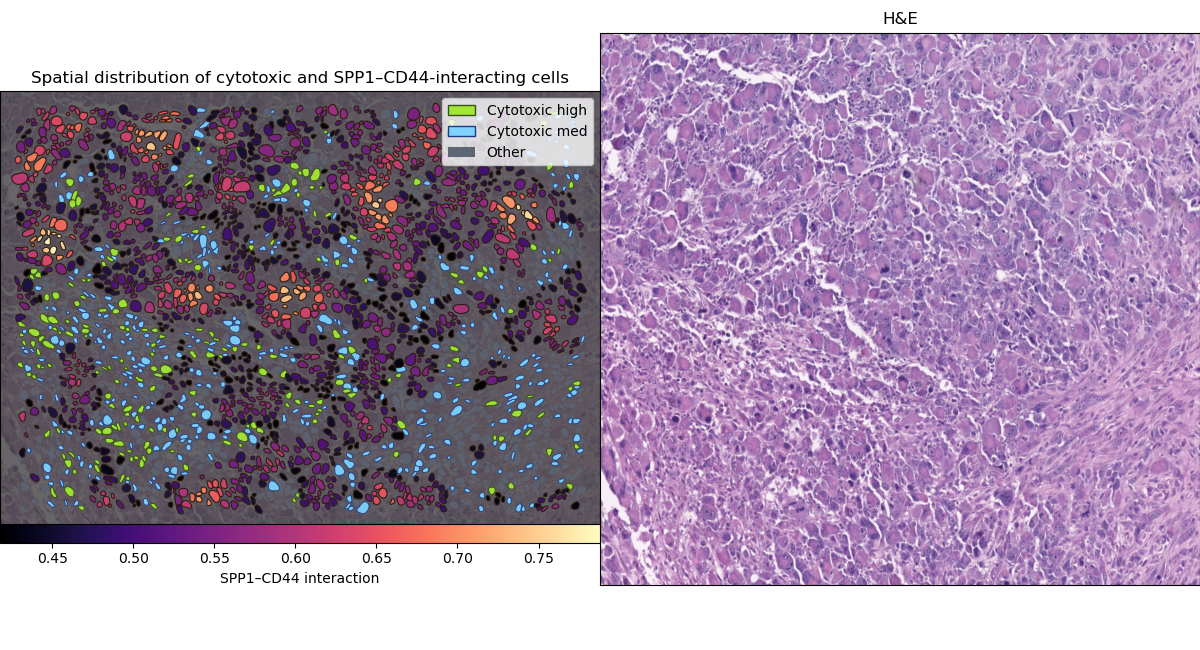

In [335]:
# --- sanity checks & robust typing ---
# redo h,w as plain Python ints (not numpy objects)
h = int(img_crop.shape[0])
w = int(img_crop.shape[1])

# guard against degenerate crops (0 width/height)
if h < 2 or w < 2:
    # expand by 1 px if possible
    ymax = min(H, ymax + 1)
    xmax = min(W, xmax + 1)
    img_crop = img[ymin:ymax, xmin:xmax]
    h = int(img_crop.shape[0]); w = int(img_crop.shape[1])
    assert h >= 2 and w >= 2, f"Crop too small: h={h}, w={w}. Check selection/pad."

# build adjusted image (LEFT) with robust casting & NaN handling
imgL = img_crop.astype(np.float32)
mx = float(imgL.max())
imgL = imgL / (65535.0 if mx > 255.0 else 255.0)
imgL = np.clip(imgL * float(he_brightness_left), 0.0, 1.0)
if float(he_gamma_left) != 1.0:
    imgL = np.clip(imgL ** float(he_gamma_left), 0.0, 1.0)
# replace any NaNs/infs just in case
imgL = np.nan_to_num(imgL, nan=0.0, posinf=1.0, neginf=0.0)

extent_left  = (0.0, float(w), float(h), 0.0)
extent_right = extent_left

fig, (axL, axR) = plt.subplots(ncols=2, figsize=(12, 6.5),
                               gridspec_kw={'wspace': 0.001}) 
# Setting up plot adjustments
fig.subplots_adjust(left=0.0, right=1, top=0.95, bottom=0.1,
                    wspace=0.002, hspace=0.0)

# LEFT: adjusted H&E
axL.imshow(imgL, origin="upper", extent=extent_left, aspect='auto', alpha=float(he_alpha_left))
axL.set_xlim(0, w); axL.set_ylim(h, 0)

# RIGHT: raw H&E
axR.imshow(img_crop, origin="upper", extent=extent_right, aspect='auto')
axR.set_xlim(0, w); axR.set_ylim(h, 0)

for ax in (axL, axR):
    ax.margins(0)  # no extra padding around images

# ---------- polygons on LEFT (unchanged) ----------
sub = gdf_sel[gdf_sel["category"] == "OTHER"]
if not sub.empty:
    sub.plot(ax=axL, facecolor=col_other, edgecolor="none", linewidth=0.3, alpha=0.85, zorder=1)

sub = gdf_sel[gdf_sel["category"] == "CYTO_MED"]
if not sub.empty:
    sub.plot(ax=axL, facecolor=col_cyto_med, edgecolor="#1e3a8a", linewidth=0.6, alpha=0.95, zorder=2)

sub = gdf_sel[gdf_sel["category"] == "CYTO_VHIGH"]
if not sub.empty:
    sub.plot(ax=axL, facecolor=col_cyto_vhi, edgecolor=edge_cyto_vhi, linewidth=0.7, alpha=0.96, zorder=3)

sub = gdf_sel[gdf_sel["category"] == "INT_HIGH"]
if not sub.empty:
    colors = sub["int_val"].map(lambda v: cmap_int(norm_int(v)))
    sub.plot(ax=axL, color=list(colors.values), edgecolor="#2b1d0e", linewidth=0.8, alpha=0.96, zorder=4)

# colorbar (unchanged)
if v_int.size:
    m_int = cm.ScalarMappable(norm=norm_int, cmap=cmap_int); m_int.set_array([])
    pos = axL.get_position()               # [x0, y0, width, height] in figure coords
    gap = 0.025                            # vertical gap under axL (shrink if you want it tighter)
    cax = fig.add_axes([pos.x0, pos.y0 - gap, pos.width, 0.028])
    cbar = fig.colorbar(m_int, cax=cax, orientation="horizontal")
    cbar.set_label("SPP1–CD44 interaction")

axL.set_title("Spatial distribution of cytotoxic and SPP1–CD44-interacting cells")
axR.set_title("H&E")
for ax in (axL, axR):
    ax.set_xticks([]); ax.set_yticks([])


legend = [
    Patch(facecolor=col_cyto_vhi, edgecolor=edge_cyto_vhi, label="Cytotoxic high"),
    Patch(facecolor=col_cyto_med, edgecolor= edge_col_cyto_med, label=f"Cytotoxic med"),
    Patch(facecolor=col_other, edgecolor="none", label="Other")
]
axL.legend(handles=legend, loc="upper right", frameon=True)
# fig.subplots_adjust(left=0.06, right=0.98, top=0.96, bottom=0.20, wspace=0.22)

# plt.tight_layout(rect=[0.00, 0.13, 1.00, 1.00])
# pad around whole layoud, w_pad: pad between plots, h_pad: height padding between plots, 

# plt.tight_layout()
plt.show()


## Plot 2 - With med as other

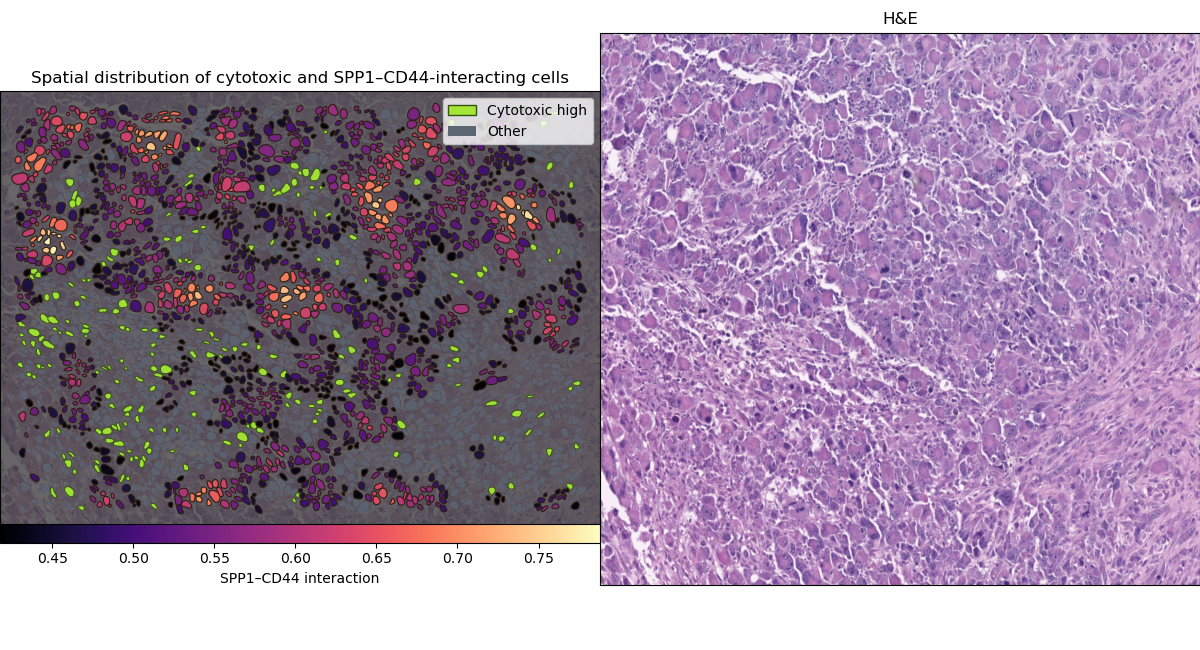

In [336]:
# ---- SECOND FIGURE: plot with CYTO_MED treated as OTHER ----
# We merge categories only for plotting; no changes to your masks/gdf_sel.
gdf2 = gdf_sel.copy()
gdf2["category_plot"] = np.where(gdf2["category"] == "CYTO_MED", "OTHER", gdf2["category"])

fig2, (axL2, axR2) = plt.subplots(ncols=2, figsize=(12, 6.5),
                                  gridspec_kw={'wspace': 0.001})
fig2.subplots_adjust(left=0.0, right=1, top=0.95, bottom=0.1, wspace=0.002, hspace=0.0)

# LEFT: adjusted H&E (same parameters as first fig)
axL2.imshow(imgL, origin="upper", extent=extent_left, aspect='auto', alpha=float(he_alpha_left))
axL2.set_xlim(0, w); axL2.set_ylim(h, 0)

# RIGHT: raw H&E (same parameters as first fig)
axR2.imshow(img_crop, origin="upper", extent=extent_right, aspect='auto')
axR2.set_xlim(0, w); axR2.set_ylim(h, 0)

for ax in (axL2, axR2):
    ax.margins(0)

# ---------- polygons on LEFT with MED→OTHER ----------
sub = gdf2[gdf2["category_plot"] == "OTHER"]
if not sub.empty:
    sub.plot(ax=axL2, facecolor=col_other, edgecolor="none", linewidth=0.3, alpha=0.85, zorder=1)

# NOTE: no separate CYTO_MED layer now (it was merged into OTHER above)

sub = gdf2[gdf2["category_plot"] == "CYTO_VHIGH"]
if not sub.empty:
    sub.plot(ax=axL2, facecolor=col_cyto_vhi, edgecolor=edge_cyto_vhi, linewidth=0.7, alpha=0.96, zorder=3)

sub = gdf2[gdf2["category_plot"] == "INT_HIGH"]
if not sub.empty:
    colors = sub["int_val"].map(lambda v: cmap_int(norm_int(v)))
    sub.plot(ax=axL2, color=list(colors.values), edgecolor="#2b1d0e", linewidth=0.8, alpha=0.96, zorder=4)

# colorbar (same logic as first fig)
if v_int.size:
    m_int2 = cm.ScalarMappable(norm=norm_int, cmap=cmap_int); m_int2.set_array([])
    pos2 = axL2.get_position()
    gap2 = 0.025
    cax2 = fig2.add_axes([pos2.x0, pos2.y0 - gap2, pos2.width, 0.028])
    cbar2 = fig2.colorbar(m_int2, cax=cax2, orientation="horizontal")
    cbar2.set_label("SPP1–CD44 interaction")

axL2.set_title("Spatial distribution of cytotoxic and SPP1–CD44-interacting cells")
axR2.set_title("H&E")
for ax in (axL2, axR2):
    ax.set_xticks([]); ax.set_yticks([])

# Legend (drop the MED entry, since it's merged)
legend2 = [
    Patch(facecolor=col_cyto_vhi, edgecolor=edge_cyto_vhi, label="Cytotoxic high"),
    Patch(facecolor=col_other,     edgecolor="none",       label="Other")
]
axL2.legend(handles=legend2, loc="upper right", frameon=True)

plt.show()


In [296]:
# import matplotlib as mpl, matplotlib.pyplot as plt
# mpl.get_backend(), plt.get_fignums() 

# Save HnE Image

In [337]:
OUT_DIR = Path(f"/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/selection_crops/{SELECTION_NAME}")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ensure `rep` exists (from the logging cell)
try:
    _ = rep
except NameError:
    rep = 1  # fallback if saving without logging

stem = f"{SELECTION_NAME}__rep{int(rep):02d}"
stem_a = f"{stem}__orig"          # first figure (MED shown separately)
stem_b = f"{stem}__MEDasOTHER"    # second figure (MED merged into OTHER)

# --- save first figure ---
fig.savefig(OUT_DIR / f"{stem_a}.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
fig.savefig(OUT_DIR / f"{stem_a}.pdf", dpi=300, bbox_inches="tight", pad_inches=0.02)

# --- save second figure ---
fig2.savefig(OUT_DIR / f"{stem_b}.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
fig2.savefig(OUT_DIR / f"{stem_b}.pdf", dpi=300, bbox_inches="tight", pad_inches=0.02)

print("Saved:", OUT_DIR / f"{stem_a}.png")
print("Saved:", OUT_DIR / f"{stem_a}.pdf")
print("Saved:", OUT_DIR / f"{stem_b}.png")
print("Saved:", OUT_DIR / f"{stem_b}.pdf")


Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/selection_crops/RTCyPSCA_2_4/RTCyPSCA_2_4__rep03__orig.png
Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/selection_crops/RTCyPSCA_2_4/RTCyPSCA_2_4__rep03__orig.pdf
Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/selection_crops/RTCyPSCA_2_4/RTCyPSCA_2_4__rep03__MEDasOTHER.png
Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/selection_crops/RTCyPSCA_2_4/RTCyPSCA_2_4__rep03__MEDasOTHER.pdf


In [231]:
plt.close('all')

# Bar Plot

In [311]:
#Load and sanity check
import numpy as np, pandas as pd
from pathlib import Path

RUN_LOG = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/selection_runs.csv")
runs = pd.read_csv(RUN_LOG)

assert not runs.empty, "RUN_LOG is empty. Collect selections first."
need = {"selection","rep","p_med","p_high","p_int","n_sel"}
missing = need - set(runs.columns)
assert not missing, f"RUN_LOG missing columns: {missing}"

# summary print
print(f"Selections in log: {runs['selection'].nunique()} samples, {len(runs)} total rows")
display(runs.groupby("selection")["rep"].nunique().rename("n_reps").reset_index())


Selections in log: 5 samples, 15 total rows


,selection,n_reps
0,CyPSCA_1_1,3
1,CyPSCA_1_2,3
2,NoTx_2_2,3
3,RTCyPSCA_1_4,3
4,RTCyPSCA_2_4,3


In [312]:
# Aggregate mean ± SEM per sample (selection)
def sem(x):
    x = np.asarray(x, float)
    return np.nan if len(x) <= 1 else x.std(ddof=1)/np.sqrt(len(x))

agg = (runs.groupby("selection", as_index=False)
           .agg(n_reps=("rep","nunique"),
                p_med_mean=("p_med","mean"),  p_med_sem=("p_med",sem),
                p_high_mean=("p_high","mean"),p_high_sem=("p_high",sem),
                p_int_mean=("p_int","mean"),  p_int_sem=("p_int",sem),
                n_sel_total=("n_sel","sum")))

print("Per-sample replicate summary (mean ± SEM):")
display(agg)


Per-sample replicate summary (mean ± SEM):


,selection,n_reps,p_med_mean,p_med_sem,p_high_mean,p_high_sem,p_int_mean,p_int_sem,n_sel_total
0,CyPSCA_1_1,3,0.120863,0.002419,0.029050,0.004843,0.549993,0.000034,5711
1,CyPSCA_1_2,3,0.131935,0.009173,0.054018,0.011189,0.549996,0.000059,8351
2,NoTx_2_2,3,0.069382,0.005042,0.007162,0.002785,0.550062,0.000056,7590
3,RTCyPSCA_1_4,3,0.094037,0.006499,0.024038,0.001836,0.549951,0.000070,3664
4,RTCyPSCA_2_4,3,0.120022,0.008867,0.049058,0.016767,0.550059,0.000065,7930


Saved nothing yet — run the next cell to export.


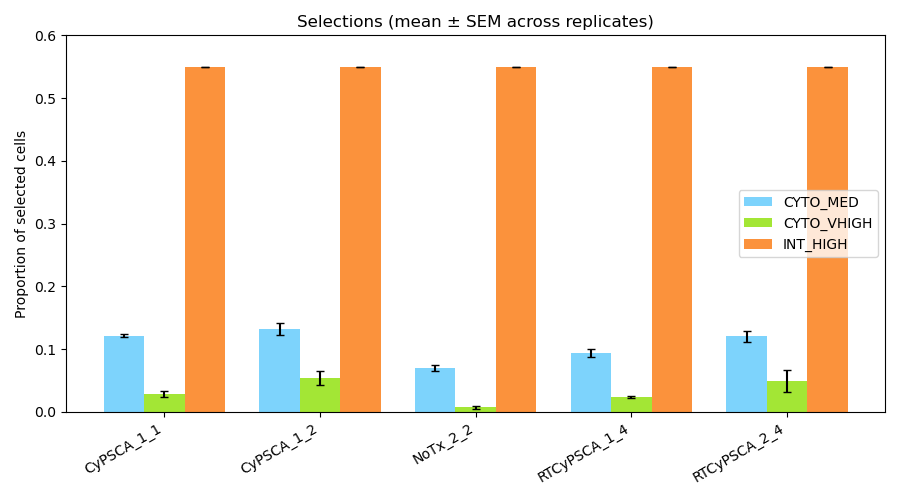

In [313]:
#Plotting
import matplotlib.pyplot as plt
import numpy as np

COL_MED  = "#7dd3fc"
COL_HIGH = "#a3e635"
COL_INT  = "#fb923c"

labels = agg["selection"].tolist()
x = np.arange(len(labels))
width = 0.26

fig, ax = plt.subplots(figsize=(max(8, 1.0*len(labels)+4), 5))
ax.bar(x - width, agg["p_med_mean"],  width, yerr=agg["p_med_sem"],  capsize=3, color=COL_MED,  label="CYTO_MED")
ax.bar(x,         agg["p_high_mean"], width, yerr=agg["p_high_sem"], capsize=3, color=COL_HIGH, label="CYTO_VHIGH")
ax.bar(x + width, agg["p_int_mean"],  width, yerr=agg["p_int_sem"],  capsize=3, color=COL_INT,  label="INT_HIGH")

ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylabel("Proportion of selected cells")
ax.set_title("Selections (mean ± SEM across replicates)")
ax.set_ylim(0, max(0.02, float( (agg[["p_med_mean","p_high_mean","p_int_mean"]].to_numpy().max() + 0.05) )))
ax.legend(frameon=True)
plt.tight_layout()

# brief summary at end of cell
print("Saved nothing yet — run the next cell to export.")


In [ ]:
# # Saving
# from pathlib import Path
# OUT_DIR = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots_final/")
# OUT_DIR.mkdir(parents=True, exist_ok=True)

# STEM = "Selections__mean±SEM"
# for ext in ["png", "pdf"]:
#     path = OUT_DIR / f"{STEM}.{ext}"
#     fig.savefig(path, dpi=300, bbox_inches="tight", pad_inches=0.02)
#     print("Saved:", path)


In [315]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# --- output location ---
OUT_DIR = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots_final/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- colors ---
COL_MED  = "#7dd3fc"
COL_HIGH = "#a3e635"
COL_INT  = "#fb923c"

labels = agg["selection"].tolist()
x = np.arange(len(labels))
width = 0.26

fig, ax = plt.subplots(figsize=(max(8, 1.0*len(labels)+4), 5))
ax.bar(x - width, agg["p_med_mean"],  width, yerr=agg["p_med_sem"],  capsize=3, color=COL_MED,  label="CYTO_MED")
ax.bar(x,         agg["p_high_mean"], width, yerr=agg["p_high_sem"], capsize=3, color=COL_HIGH, label="CYTO_VHIGH")
ax.bar(x + width, agg["p_int_mean"],  width, yerr=agg["p_int_sem"],  capsize=3, color=COL_INT,  label="INT_HIGH")

ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylabel("Proportion of selected cells")
ax.set_title("Selections (mean ± SEM across replicates)")

ylim_auto = float(agg[["p_med_mean","p_high_mean","p_int_mean"]].to_numpy().max()) + 0.05
ax.set_ylim(0, max(0.02, ylim_auto))
ax.legend(frameon=True)
plt.tight_layout()

STEM = "Selections__mean±SEM__ALL"
fig.savefig(OUT_DIR / f"{STEM}.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
fig.savefig(OUT_DIR / f"{STEM}.pdf", dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.close(fig)

print("Saved:", OUT_DIR / f"{STEM}.png")
print("Saved:", OUT_DIR / f"{STEM}.pdf")


Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots_final/Selections__mean±SEM__ALL.png
Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots_final/Selections__mean±SEM__ALL.pdf


In [316]:
import matplotlib.pyplot as plt
import numpy as np

# map: column -> (pretty label, color)
CATS = {
    "p_med":  ("CYTO_MED",  "#7dd3fc"),
    "p_high": ("CYTO_VHIGH","#a3e635"),
    "p_int":  ("INT_HIGH",  "#fb923c"),
}

labels = agg["selection"].tolist()
x = np.arange(len(labels))

# Optional fixed y-limits per category (uncomment to enforce)
# YLIMS = {"p_med": 0.40, "p_high": 0.10, "p_int": 0.40}
YLIMS = {}

for key, (pretty, color) in CATS.items():
    y    = agg[f"{key}_mean"].to_numpy()
    yerr = agg[f"{key}_sem"].to_numpy()

    fig, ax = plt.subplots(figsize=(max(6.5, 0.9*len(labels)+3), 4.5))
    ax.bar(x, y, 0.6, yerr=yerr, capsize=3, color=color)

    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylabel("Proportion of selected cells")
    ax.set_title(f"{pretty} (mean ± SEM across replicates)")

    if key in YLIMS:
        ax.set_ylim(0, YLIMS[key])
    else:
        ax.set_ylim(0, max(0.02, float(y.max()) + 0.05))

    plt.tight_layout()

    STEM = f"Selections__mean±SEM__{pretty}"
    fig.savefig(OUT_DIR / f"{STEM}.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
    fig.savefig(OUT_DIR / f"{STEM}.pdf", dpi=300, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

    print("Saved:", OUT_DIR / f"{STEM}.png")
    print("Saved:", OUT_DIR / f"{STEM}.pdf")


Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots_final/Selections__mean±SEM__CYTO_MED.png
Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots_final/Selections__mean±SEM__CYTO_MED.pdf
Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots_final/Selections__mean±SEM__CYTO_VHIGH.png
Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots_final/Selections__mean±SEM__CYTO_VHIGH.pdf
Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots_final/Selections__mean±SEM__INT_HIGH.png
Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots_final/Selections__mean±SEM__INT_HIGH.pdf
